## Urszula Michalska, Natalia Rogalska


In [1]:
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay, classification_report
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import RandomizedSearchCV
import numpy as np
import time

In [2]:
X_train = pd.read_csv("X_train.csv")
X_test = pd.read_csv("X_test.csv")
y_train = pd.read_csv("y_train.csv")
y_test = pd.read_csv("y_test.csv")

In [3]:
dt = DecisionTreeClassifier()

param_grid = {
    'criterion' :  ['gini', 'entropy', 'log_loss'],
    'max_depth' :  range(1,20),
    'min_samples_split' :  range (2,10),
    'min_samples_leaf' :  range (1,10),
    'ccp_alpha' :  np.linspace(0,0.05,10),
    'max_features': [None, "sqrt", "log2"],
}

start = time.perf_counter()

dt = RandomizedSearchCV(
    estimator=dt,
    param_distributions=param_grid,
    cv=3,
    scoring='accuracy',
    n_jobs=-1
)

dt.fit(X_train, y_train)
end = time.perf_counter()

print(f"Elapsed time: {end - start:.6f} seconds")


Elapsed time: 5.294217 seconds


In [5]:
start = time.perf_counter()

dt_best =DecisionTreeClassifier(**dt.best_params_)
dt_best.fit(X_train,y_train)
dt_best.score(X_test,y_test)
y_pred_best = dt_best.predict(X_test)
end = time.perf_counter()

print(f"Elapsed time: {end - start:.6f} seconds")

Elapsed time: 0.023901 seconds


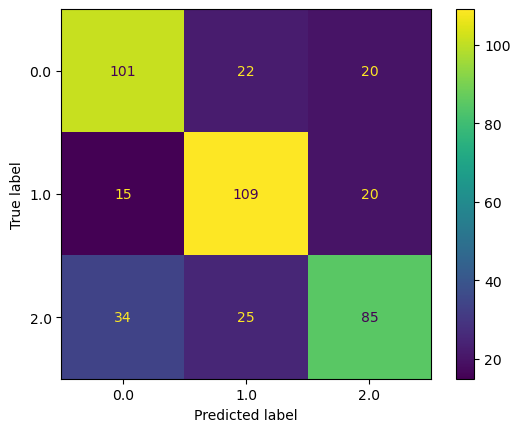

In [8]:
cm = confusion_matrix(y_test, y_pred_best, labels=dt_best.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=dt_best.classes_)
disp.plot()

In [10]:
class_report = classification_report(y_test, y_pred_best)
print("Classification Report:")
print(class_report)
print(f"Accuracy: {accuracy_score(y_test, y_pred_best)}")

Classification Report:
              precision    recall  f1-score   support

         0.0       0.67      0.71      0.69       143
         1.0       0.70      0.76      0.73       144
         2.0       0.68      0.59      0.63       144

    accuracy                           0.68       431
   macro avg       0.68      0.68      0.68       431
weighted avg       0.68      0.68      0.68       431

Accuracy: 0.6844547563805105
